# Applied Statistics for Data Science with Python


# Chapter 1: Random Events, Variables & Probability Modeling

by Gal Arav M.Sc. © 2026
Licensed under CC BY‑NC 4.0 — see the LICENSE file in this repository for details  
https://qikly.com

## Learning Objectives  

This notebook accompanies the book's Chapter 1 with these objectives:

- Explain how random events arise and how random variables represent uncertainty.  
- Describe expectation, variance and the role of independent samples.  
- Interpret common distribution shapes and basic visualization tools.  
- Distinguish continuous and discrete distributions and understand their key features.  
- Separate populations from samples and explain the roles of parameters and statistics.  
- Understand how sampling variability leads to major statistical results.  
- Summarize core event generation models, including Bernoulli, binomial, geometric, exponential and Poisson processes.





In [1]:
# Utility function to save a high‑resolution figure for the textbook
# Images are saved temporarily in Google Colab and disappear when the session ends
import matplotlib.pyplot as plt
import os

def export_plot(fig, plot_id, dpi=300, width=8, height=5, outdir="exports"):
    fig.set_size_inches(width, height)
    fig.subplots_adjust(left=0.12, right=0.95, top=0.87, bottom=0.15)
    os.makedirs(outdir, exist_ok=True)
    fig.savefig(f"{outdir}/{plot_id}.png", dpi=dpi, bbox_inches=None, pad_inches=0.45)

## Random Events & Variables

###  Expected Value formula

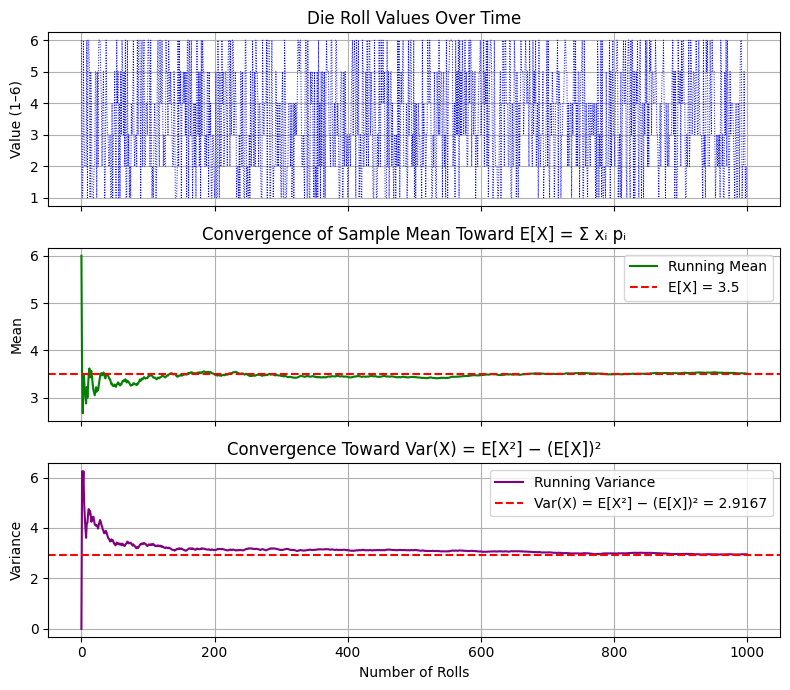

In [2]:
# Visual demonstration of:
# 1. Raw values of a discrete random variable (fair die)
# 2. Convergence of the sample mean toward E[X] = Σ xᵢ pᵢ = 3.5
# 3. Convergence of the sample variance toward Var(X) = E[X²] − (E[X])²
#
# Worked-out values for a fair die:
#   E[X]   = (1+2+3+4+5+6)/6 = 3.5
#   E[X²]  = (1²+2²+3²+4²+5²+6²)/6 = 91/6 ≈ 15.1667
#   (E[X])² = 3.5² = 12.25
#   Var(X) = E[X²] − (E[X])² = 15.1667 − 12.25 = 2.9167
#
# This illustrates the Law of Large Numbers for both mean and variance.

import random
import matplotlib.pyplot as plt

random.seed(42)  # repeatable simulation

def roll_die():
    return random.randint(1, 6)

averages = []
values = []
variances = []

total = 0
sum_sq = 0
N = 1000  # number of rolls

for n in range(1, N + 1):
    x = roll_die()
    values.append(x)
    total += x
    sum_sq += x * x

    mean = total / n
    averages.append(mean)

    # Var(X) = E[X^2] - (E[X])^2
    ex2 = sum_sq / n
    var = ex2 - mean**2
    variances.append(var)

true_mean = 3.5
true_var = 35/12  # ≈ 2.9167

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

# --- Plot 1: Raw die values ---
axes[0].plot(values, color='blue',  linestyle='dotted', linewidth=0.7)
axes[0].set_title("Die Roll Values Over Time")
axes[0].set_ylabel("Value (1–6)")
axes[0].grid(True)

# --- Plot 2: Running mean ---
axes[1].plot(averages, label="Running Mean", color='green')
axes[1].axhline(true_mean, color='red', linestyle='--', label="E[X] = 3.5")
axes[1].set_title("Convergence of Sample Mean Toward E[X] = Σ xᵢ pᵢ")
axes[1].set_ylabel("Mean")
axes[1].legend()
axes[1].grid(True)

# --- Plot 3: Running variance ---
axes[2].plot(variances, label="Running Variance", color='purple')
axes[2].axhline(true_var, color='red', linestyle='--',
                label="Var(X) = E[X²] − (E[X])² = 2.9167")
axes[2].set_title("Convergence Toward Var(X) = E[X²] − (E[X])²")
axes[2].set_xlabel("Number of Rolls")
axes[2].set_ylabel("Variance")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_long_run_behavior", height=7)

## Distribution Structure & Shape

### Continuous vs. Discrete Uniform Distribution

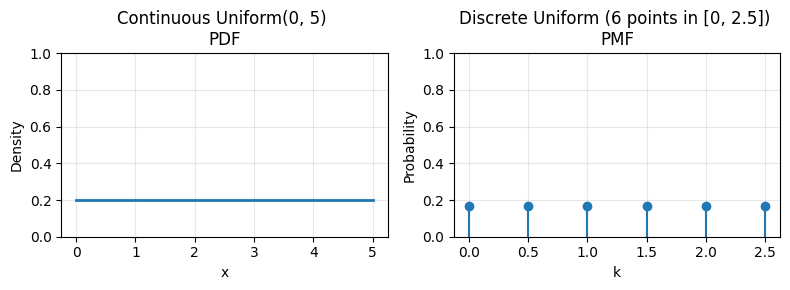

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Continuous Uniform on [0,5] — PDF
grid_cont = np.linspace(0, 5, 500)
pdf_cont = uniform.pdf(grid_cont, loc=0, scale=5)

axes[0].plot(grid_cont, pdf_cont, linewidth=2)
axes[0].set_title("Continuous Uniform(0, 5) \nPDF")
axes[0].set_ylim(0, 1)   # shared y-scale
axes[0].set_xlabel("x")
axes[0].set_ylabel("Density")
axes[0].grid(True, alpha=0.3)

# Discrete Uniform on 6 points in [0,2.5] — PMF
n = 6
grid_disc = np.linspace(0, 2.5, n)
pmf_disc = np.ones(n) / n

axes[1].stem(grid_disc, pmf_disc, basefmt=" ", markerfmt="o", linefmt="C0-", bottom=0)
axes[1].set_title("Discrete Uniform (6 points in [0, 2.5]) \nPMF")
axes[1].set_ylim(0, 1)   # same y-scale as PDF
axes[1].set_xlabel("k")
axes[1].set_ylabel("Probability")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_pdf_vs_pmf")

### The Four Moments

| Moment | Uses (Power of X) | What It Weights | What It Reveals |
|--------|--------------------|------------------|------------------|
| **1st moment (Mean)** | X¹ | Values proportionally | Center **location** |
| **2nd moment (Variance)** | X² | Larger deviations | **Spread** around the mean |
| **3rd moment (Skewness)** | X³ | Positive vs. negative deviations | **Asymmetry** |
| **4th moment (Kurtosis)** | X⁴ | Extreme values | Influence of the **tails** and outliers |


### PDFs for the four moments

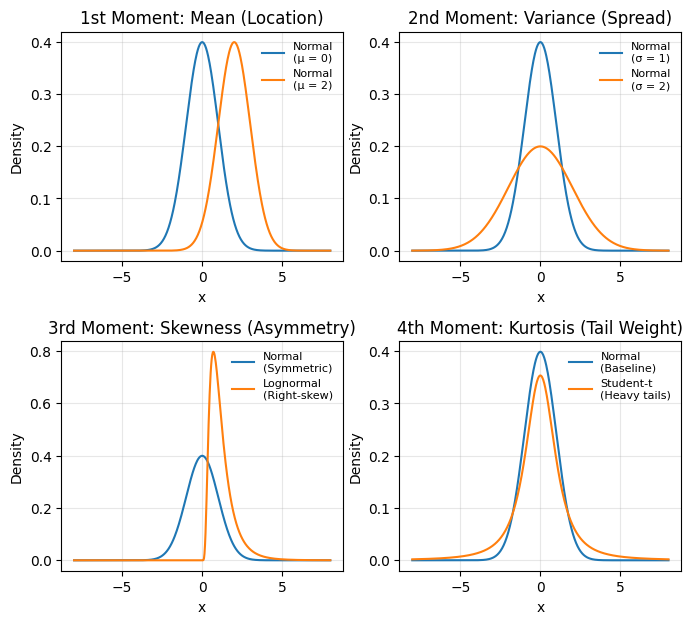

In [4]:
# ============================================================
# PDFs for the four moments
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Grid
x = np.linspace(-8, 8, 500)

# Distributions chosen to illustrate each moment
dist_mean = stats.norm(loc=2, scale=1)             # shifted mean
dist_var = stats.norm(loc=0, scale=2)              # larger variance
dist_skew = stats.lognorm(s=0.6, scale=np.exp(0))  # right-skewed
dist_kurt = stats.t(df=2)                          # heavier-tailed Student-t

fig, axes = plt.subplots(2, 2, figsize=(8, 7), gridspec_kw={"hspace": 0.35})

LEGEND_KW = dict(fontsize=8, frameon=False, loc="upper right")

# 1st Moment
axes[0, 0].plot(x, stats.norm.pdf(x, 0, 1), label="Normal\n(μ = 0)")
axes[0, 0].plot(x, dist_mean.pdf(x), label="Normal\n(μ = 2)")
axes[0, 0].set_title("1st Moment: Mean (Location)")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend(**LEGEND_KW)
axes[0, 0].grid(alpha=0.3)

# 2nd Moment
axes[0, 1].plot(x, stats.norm.pdf(x, 0, 1), label="Normal\n(σ = 1)")
axes[0, 1].plot(x, dist_var.pdf(x), label="Normal\n(σ = 2)")
axes[0, 1].set_title("2nd Moment: Variance (Spread)")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend(**LEGEND_KW)
axes[0, 1].grid(alpha=0.3)

# 3rd Moment
axes[1, 0].plot(x, stats.norm.pdf(x, 0, 1), label="Normal\n(Symmetric)")
axes[1, 0].plot(x, dist_skew.pdf(x), label="Lognormal\n(Right-skew)")
axes[1, 0].set_title("3rd Moment: Skewness (Asymmetry)")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend(**LEGEND_KW)
axes[1, 0].grid(alpha=0.3)

# 4th Moment
axes[1, 1].plot(x, stats.norm.pdf(x, 0, 1), label="Normal\n(Baseline)")
axes[1, 1].plot(x, dist_kurt.pdf(x), label="Student-t\n(Heavy tails)")
axes[1, 1].set_title("4th Moment: Kurtosis (Tail Weight)")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend(**LEGEND_KW)
axes[1, 1].grid(alpha=0.3)

plt.show()
export_plot(fig, "sim_pdfs_for_the_4_moments", height=7)

### Histograms, KDE, CDF

### Normal Distribution Example

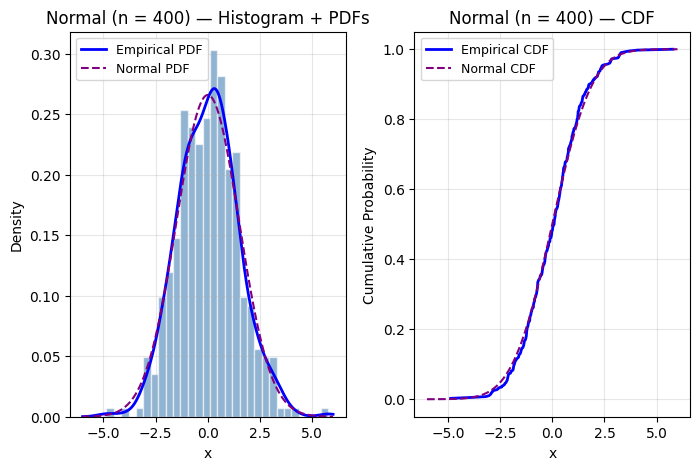

In [5]:
# ============================================================
# Normal Distribution Example (variable n)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

def plot_normal_example(n, mu=0, sigma=1.5, bins=30):
    np.random.seed(42)

    # Generate Normal sample
    data = np.random.normal(mu, sigma, n)
    grid = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)

    # Theoretical PDF & CDF
    theo_pdf = norm.pdf(grid, mu, sigma)
    theo_cdf = norm.cdf(grid, mu, sigma)

    # Empirical PDF (KDE)
    kde = gaussian_kde(data)
    emp_pdf = kde(grid)

    # Empirical CDF
    sorted_data = np.sort(data)
    emp_cdf = np.arange(1, len(data)+1) / len(data)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={"wspace": 0.25})

    # LEFT: Histogram + PDFs
    axes[0].hist(data, bins=bins, density=True, alpha=0.6,
                 color="steelblue", edgecolor="white")
    axes[0].plot(grid, emp_pdf, color="blue", linewidth=2, label="Empirical PDF")
    axes[0].plot(grid, theo_pdf, color="purple", linestyle="--",
                 linewidth=1.5, label="Normal PDF")
    axes[0].set_title(f"Normal (n = {n}) — Histogram + PDFs")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("Density")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=9)

    # RIGHT: CDFs
    axes[1].plot(sorted_data, emp_cdf, color="blue", linewidth=2, label="Empirical CDF")
    axes[1].plot(grid, theo_cdf, color="purple", linestyle="--",
                 linewidth=1.5, label="Normal CDF")
    axes[1].set_title(f"Normal (n = {n}) — CDF")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("Cumulative Probability")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=9)

    plt.show()
    return fig


# Generate and export the figure
fig = plot_normal_example(400)
export_plot(fig, "sim_histograms_kde_cdf", height=7)

#### Normal Plot for Various Values of Sigma

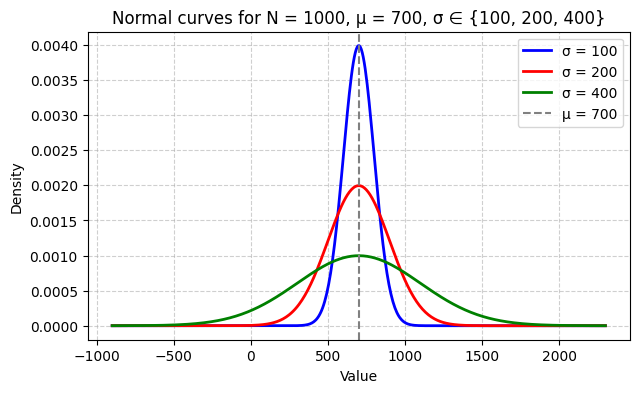

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(0)

# Simulation parameters
n = 1000
mu = 700
sigmas = [100, 200, 400]

# Colors for each sigma
colors = {
    100: "blue",
    200: "red",
    400: "green"
}

# Figure size 7x4
fig, ax = plt.subplots(figsize=(7, 4))

xs = np.linspace(mu - 4*max(sigmas), mu + 4*max(sigmas), 500)

for sigma in sigmas:
    ys = norm.pdf(xs, mu, sigma)
    ax.plot(xs, ys, lw=2, color=colors[sigma], label=f"σ = {sigma}")

ax.axvline(mu, color="gray", linestyle="--", linewidth=1.5, label=f"μ = {mu}")

ax.set_xlabel("Value", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.set_title(f"Normal curves for N = 1000, μ = {mu}, σ ∈ {{100, 200, 400}}", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(fontsize=10)

plt.show()
export_plot(fig, "sim_normal_3_sigma_values")

#### Standard Deviation and z Scores

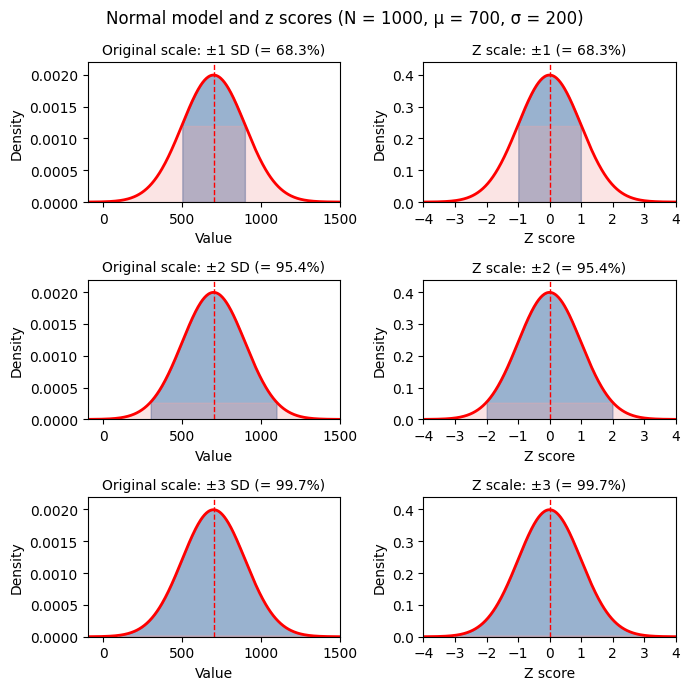

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(0)

# Simulation parameters
n = 1000
mu = 700
sigma = 200

data = np.random.normal(mu, sigma, n)
z = (data - mu) / sigma

z_values = [1, 2, 3]

# Figure: 8 inches wide, 3 rows × 2.5 inches tall
fig, axes = plt.subplots(3, 2, figsize=(7, 7))

# True peak heights
peak_orig = norm.pdf(mu, mu, sigma)
peak_z    = norm.pdf(0)

YLIM_ORIG = 1.1 * peak_orig
YLIM_Z    = 1.1 * peak_z

for i, zcut in enumerate(z_values):
    pct = (norm.cdf(zcut) - norm.cdf(-zcut)) * 100

    # ---------- LEFT: ORIGINAL SCALE ----------
    ax = axes[i, 0]
    xs = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    ys = norm.pdf(xs, mu, sigma)

    mask = (xs >= mu - zcut*sigma) & (xs <= mu + zcut*sigma)
    ax.fill_between(xs[mask], ys[mask], color="#003f87", alpha=0.4)
    ax.fill_between(xs[~mask], ys[~mask], color="#f4a6a6", alpha=0.3)
    ax.plot(xs, ys, "r", lw=2)

    ax.axvline(mu, color="r", linestyle="--", linewidth=1)

    ax.set_xlim(mu - 4*sigma, mu + 4*sigma)
    ax.set_ylim(0, YLIM_ORIG)
    ax.set_title(f"Original scale: ±{zcut} SD (= {pct:.1f}%)", fontsize=10)

    # axis labels in 10pt
    ax.set_xlabel("Value", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.tick_params(axis="both", labelsize=10)

    # ---------- RIGHT: Z SCALE ----------
    ax = axes[i, 1]
    zs = np.linspace(-4, 4, 400)
    ys_z = norm.pdf(zs)

    mask_z = (zs >= -zcut) & (zs <= zcut)
    ax.fill_between(zs[mask_z], ys_z[mask_z], color="#003f87", alpha=0.4)
    ax.fill_between(zs[~mask_z], ys_z[~mask_z], color="#f4a6a6", alpha=0.3)
    ax.plot(zs, ys_z, "r", lw=2)

    ax.axvline(0, color="r", linestyle="--", linewidth=1)

    ax.set_xlim(-4, 4)
    ax.set_ylim(0, YLIM_Z)
    ax.set_title(f"Z scale: ±{zcut} (= {pct:.1f}%)", fontsize=10)
    ax.set_xticks(np.arange(-4, 5, 1))

    # axis labels in 10pt
    ax.set_xlabel("Z score", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.tick_params(axis="both", labelsize=10)

# Main title
fig.suptitle(f"Normal model and z scores (N = {n}, μ = {mu}, σ = {sigma})",
             fontsize=12, y=0.98)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_normal_model_z_scores", height=7)

### 2‑Mode Gaussian Mixture Model Example

A Gaussian mixture model gives you a smooth theoretical density made by blending its component Gaussians, while the empirical density comes from the actual sample you draw; the mixture PDF/CDF represent the true underlying model, and the empirical histogram/CDF show how a finite, noisy dataset approximates that model in practice


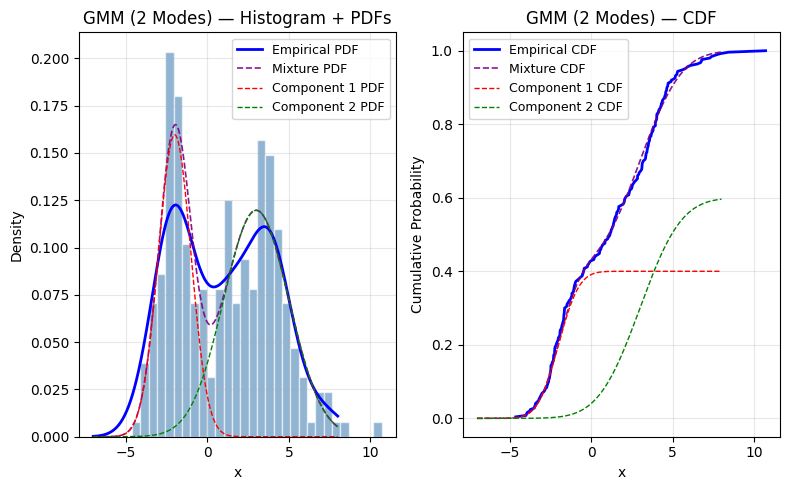

In [8]:
# ============================================================
# 2‑Mode Gaussian Mixture Model Example
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

np.random.seed(42)

# -------------------------
# Generate GMM sample
# -------------------------
n = 250

mu1, sigma1, w1 = -2, 1, 0.4
mu2, sigma2, w2 =  3, 2, 0.6

n1 = int(n * w1)
n2 = n - n1

x1 = np.random.normal(mu1, sigma1, n1)
x2 = np.random.normal(mu2, sigma2, n2)
data = np.concatenate([x1, x2])

grid = np.linspace(-7, 8, 500)

# PDFs
pdf1 = w1 * norm.pdf(grid, mu1, sigma1)
pdf2 = w2 * norm.pdf(grid, mu2, sigma2)
mix_pdf = pdf1 + pdf2

# Empirical PDF
kde = gaussian_kde(data)
emp_pdf = kde(grid)

# CDFs
cdf1 = w1 * norm.cdf(grid, mu1, sigma1)
cdf2 = w2 * norm.cdf(grid, mu2, sigma2)
mix_cdf = cdf1 + cdf2

sorted_data = np.sort(data)
emp_cdf = np.arange(1, len(data)+1) / len(data)

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ============================================================
# LEFT: Histogram + PDFs
# ============================================================
axes[0].hist(data, bins=30, density=True, alpha=0.6,
             color="steelblue", edgecolor="white")

axes[0].plot(grid, emp_pdf, color="blue", linewidth=2, label="Empirical PDF")
axes[0].plot(grid, mix_pdf, color="purple", linestyle="--",
             linewidth=1.2, alpha=0.9, label="Mixture PDF")
axes[0].plot(grid, pdf1, color="red", linestyle="--", linewidth=1.0, label="Component 1 PDF")
axes[0].plot(grid, pdf2, color="green", linestyle="--", linewidth=1.0, label="Component 2 PDF")

axes[0].set_title("GMM (2 Modes) — Histogram + PDFs")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Density")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# ============================================================
# RIGHT: CDFs
# ============================================================
axes[1].plot(sorted_data, emp_cdf, color="blue", linewidth=2, label="Empirical CDF")
axes[1].plot(grid, mix_cdf, color="purple", linestyle="--",
             linewidth=1.2, alpha=0.9, label="Mixture CDF")
axes[1].plot(grid, cdf1, color="red", linestyle="--", linewidth=1.0, label="Component 1 CDF")
axes[1].plot(grid, cdf2, color="green", linestyle="--", linewidth=1.0, label="Component 2 CDF")

axes[1].set_title("GMM (2 Modes) — CDF")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Cumulative Probability")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_gmm_2_modes")

## Core Probability Distributions

### Binomial Outcomes from Bernoulli Trials with Normal Approximation

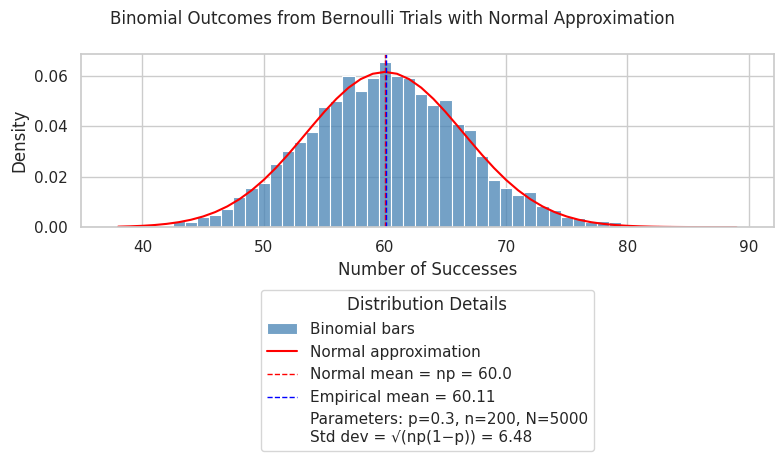

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

np.random.seed(42)
sns.set(style="whitegrid")

# -----------------------------
# Parameters
# -----------------------------
p = 0.3
n = 200
N = 5000

# -----------------------------
# Simulate Binomial outcomes
# -----------------------------
binomial_counts = np.random.binomial(n=n, p=p, size=N)

mu = n * p
sigma = np.sqrt(n * p * (1 - p))
empirical_mean = binomial_counts.mean()

x_vals = np.arange(binomial_counts.min(), binomial_counts.max() + 1)
normal_pdf = norm.pdf(x_vals, loc=mu, scale=sigma)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))
plt.suptitle("Binomial Outcomes from Bernoulli Trials with Normal Approximation", fontsize=12)

bars = sns.histplot(
    binomial_counts,
    bins=range(binomial_counts.min(), binomial_counts.max() + 1),
    stat="density",
    color="steelblue",
    discrete=True,
    ax=ax
)

# Normal approximation curve
line_normal, = ax.plot(x_vals, normal_pdf, color="red")

# Red dashed line: theoretical mean
line_normal_mean = ax.axvline(mu, color="red", linestyle="--", linewidth=1)

# Blue dashed line: empirical sample mean
line_empirical_mean = ax.axvline(empirical_mean, color="blue", linestyle="--", linewidth=1)

ax.set_xlabel("Number of Successes")

# Legend under the chart
handles = [
    bars.patches[0],            # Binomial bars
    line_normal,                # Normal curve
    line_normal_mean,           # Normal mean (red dashed)
    line_empirical_mean,        # Empirical mean (blue dashed)
    plt.Line2D([], [], color='none')  # dummy row for parameters
]

labels = [
    "Binomial bars",
    "Normal approximation",
    f"Normal mean = np = {mu:.1f}",
    f"Empirical mean = {empirical_mean:.2f}",
    f"Parameters: p={p}, n={n}, N={N}\nStd dev = √(np(1−p)) = {sigma:.2f}"
]

ax.legend(
    handles,
    labels,
    title="Distribution Details",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.32)
)

plt.subplots_adjust(bottom=0.34)
plt.tight_layout()
plt.show()
export_plot(fig, "sim_binomial_towards_normal")

### Random Walks

#### Random Walk: Mean and Variance of a Single Step

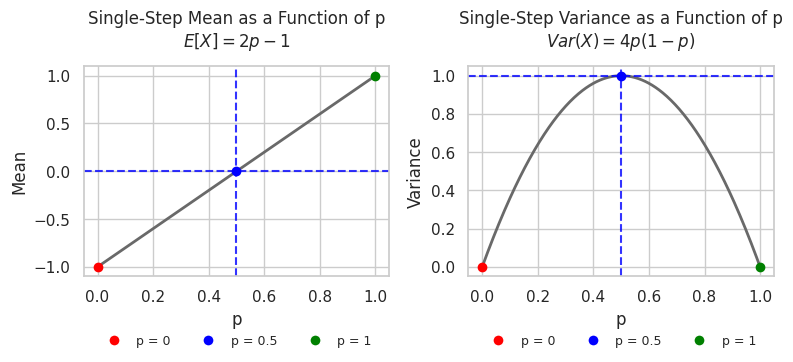

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # Required for custom legend entries

# p grid
p = np.linspace(0, 1, 400)

# theoretical single-step mean and variance
mean_theory = 2*p - 1
var_theory = 4*p*(1 - p)

# key points
p_points = np.array([0, 0.5, 1])
mean_points = 2*p_points - 1
var_points = 4*p_points*(1 - p_points)

# colors and labels for the three points
point_colors = ["red", "blue", "green"]
point_labels = ["p = 0", "p = 0.5", "p = 1"]

# Create custom legend handles: Markers only, no lines
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=point_labels[i],
           markerfacecolor=point_colors[i], markersize=8)
    for i in range(3)
]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# ---------------------------------------------------------
# 1. SINGLE-STEP MEAN
# ---------------------------------------------------------
ax = axes[0]
ax.plot(p, mean_theory, color="dimgray", linewidth=2)
ax.axvline(0.5, linestyle="--", color="blue", alpha=0.8)
ax.axhline(0, linestyle="--", color="blue", alpha=0.8)

for x, y, c in zip(p_points, mean_points, point_colors):
    ax.plot(x, y, "o", color=c)

ax.set_title("Single-Step Mean as a Function of p\n$E[X] = 2p - 1$", pad=14)
ax.set_xlabel("p")
ax.set_ylabel("Mean")
ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.grid(True)

ax.legend(handles=legend_elements, loc="upper center",
          bbox_to_anchor=(0.5, -0.22), ncol=3,
          frameon=False, fontsize=9)

# ---------------------------------------------------------
# 2. SINGLE-STEP VARIANCE
# ---------------------------------------------------------
ax = axes[1]
ax.plot(p, var_theory, color="dimgray", linewidth=2)
ax.axvline(0.5, linestyle="--", color="blue", alpha=0.8)
ax.axhline(1, linestyle="--", color="blue", alpha=0.8)

for x, y, c in zip(p_points, var_points, point_colors):
    ax.plot(x, y, "o", color=c)

ax.set_title("Single-Step Variance as a Function of p\n$Var(X) = 4p(1-p)$", pad=14)
ax.set_xlabel("p")
ax.set_ylabel("Variance")
ax.grid(True)

ax.legend(handles=legend_elements, loc="upper center",
          bbox_to_anchor=(0.5, -0.22), ncol=3,
          frameon=False, fontsize=9)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_random_walk_single_step")

#### Sample Random Walks and Distribution

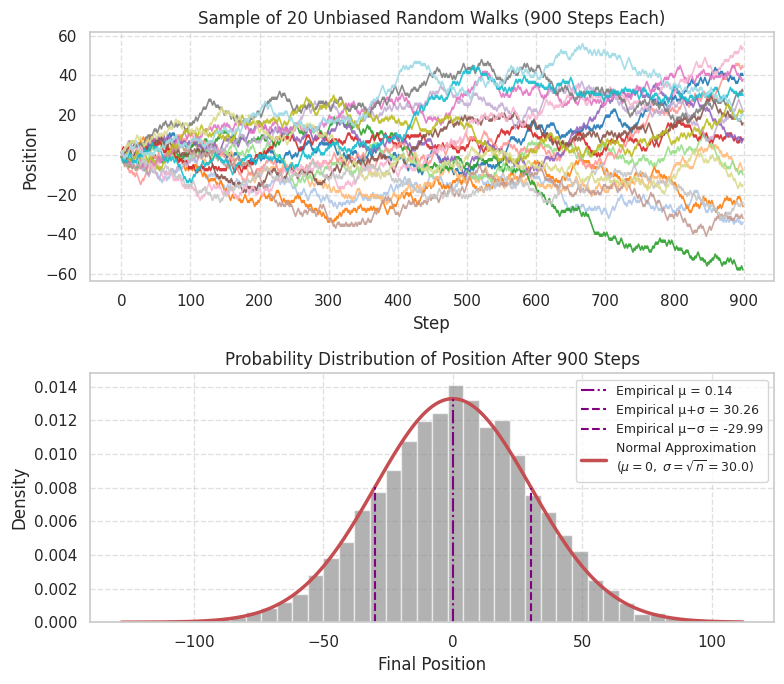

In [11]:
# ---------------------------------------------------------
# Sample Random Walks + Normal Histogram with μ/σ Lines
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# parameters
n_steps = 900
n_walks = 5000
rng = np.random.default_rng(seed=42)  # reproducible randomness

# simulate many random walks
steps = rng.choice([-1, 1], size=(n_walks, n_steps))
walks = steps.cumsum(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7))  # stacked vertically

# --- Top plot: 20 sample random walks ---
sample_indices = rng.choice(n_walks, size=20, replace=False)
cmap = plt.get_cmap('tab20')

for i, idx in enumerate(sample_indices):
    ax1.plot(walks[idx, :], linewidth=1.2, color=cmap(i % 20), alpha=0.9)

ax1.set_title("Sample of 20 Unbiased Random Walks (900 Steps Each)")
ax1.set_xlabel("Step")
ax1.set_ylabel("Position")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xticks(np.arange(0, n_steps+1, 100))

# --- Bottom plot: Histogram + Normal Curve ---
final_positions = walks[:, -1]

ax2.hist(final_positions, bins=40, density=True, alpha=0.6,
         color='gray')

# Empirical μ and σ
emp_mu = final_positions.mean()
emp_sigma = final_positions.std()

# Theoretical σ (for curve)
theo_sigma = np.sqrt(n_steps)
theo_mu = 0

# Normal curve
x_vals = np.linspace(final_positions.min(), final_positions.max(), 400)
normal_curve = (1 / (theo_sigma * np.sqrt(2 * np.pi))) * \
               np.exp(-0.5 * ((x_vals - theo_mu) / theo_sigma)**2)

# Plot the normal curve (legend entry)
normal_line = ax2.plot(
    x_vals, normal_curve, 'r-', linewidth=2.5,
    label=(
        "Normal Approximation\n"
        rf"($\mu=0,\ \sigma=\sqrt{{n}}={theo_sigma:.1f}$)"
    )
)

# Helper: short dashed vertical segments under the curve
def short_vline(x, color, linestyle, label):
    y = (1 / (theo_sigma * np.sqrt(2 * np.pi))) * \
        np.exp(-0.5 * ((x - theo_mu) / theo_sigma)**2)
    return ax2.plot([x, x], [0, y], linestyle=linestyle, color=color, label=label)

# --- Empirical μ (dash-dot) ---
emp_mu_line = short_vline(emp_mu, 'purple', '-.', rf"Empirical μ = {emp_mu:.2f}")

# --- Empirical ±σ (dashed) ---
emp_mu_plus = short_vline(emp_mu + emp_sigma, 'purple', '--',
                          rf"Empirical μ+σ = {emp_mu + emp_sigma:.2f}")
emp_mu_minus = short_vline(emp_mu - emp_sigma, 'purple', '--',
                           rf"Empirical μ−σ = {emp_mu - emp_sigma:.2f}")

ax2.set_title(f"Probability Distribution of Position After {n_steps} Steps")
ax2.set_xlabel("Final Position")
ax2.set_ylabel("Density")
ax2.grid(True, linestyle='--', alpha=0.6)

# Legend: empirical μ/σ + normal curve, with legend title
handles = [
    emp_mu_line[0], emp_mu_plus[0], emp_mu_minus[0],
    normal_line[0]
]
ax2.legend(
    handles=handles,
    fontsize=9,                 # legend item font
)

ax2.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()
export_plot(fig, "sim_sample_random_walks_and_distribution", height=7)

#### Linearity of Expectation and Accumulated Uncertainty in Unbiased Random Walks

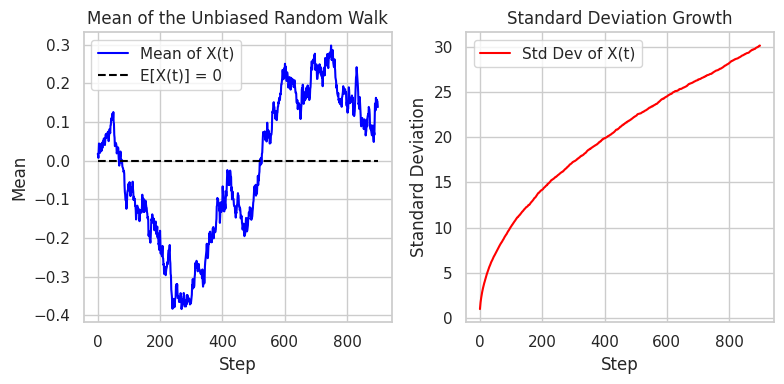

In [12]:
# ---------------------------------------------------------
# Random Walk Simulation
#
# A "step" is a single ±1 movement: the walker moves up (+1)
# or down (–1) with equal probability. After t steps, the
# position is the sum of all increments.
#
# x-axis: time (number of steps t)
# y-axis: position of the walk after t steps
#
# 1. Linearity of Expectation:
#    Each step has mean 0, so the expected position after t steps is 0.
#    Averaging many walks reveals this clean linear behavior (dashed line).
#
# 2. Accumulated Uncertainty:
#    Variances add, so the spread grows like sqrt(t). The std‑dev curve
#    shows how uncertainty increases as more independent steps accumulate.
#
# 3. Law of Large Numbers:
#    A single walk is noisy, but thousands of walks make the mean and
#    standard deviation settle into their theoretical shapes.
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# parameters
n_steps = 900
n_walks = 5000
rng = np.random.default_rng(seed=42)  # reproducible randomness

# simulate many random walks
steps = rng.choice([-1, 1], size=(n_walks, n_steps))
walks = steps.cumsum(axis=1)

# compute mean and std at each time step
mean_t = walks.mean(axis=0)
std_t = walks.std(axis=0)

# linear expectation line (E[X(t)] = 0 for symmetric walk)
linear_expectation = np.zeros(n_steps)

# plot two side-by-side charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))

# --- Left chart: Mean ---
ax1.plot(mean_t, color='blue', label='Mean of X(t)')
ax1.plot(linear_expectation, '--', color='black', label='E[X(t)] = 0')
ax1.set_title("Mean of the Unbiased Random Walk")
ax1.set_xlabel("Step")
ax1.set_ylabel("Mean")
ax1.grid(True)
ax1.legend()

# --- Right chart: Standard Deviation ---
ax2.plot(std_t, color='red', label='Std Dev of X(t)')
ax2.set_title("Standard Deviation Growth")
ax2.set_xlabel("Step")
ax2.set_ylabel("Standard Deviation")
# ax2.set_yticks(range(0, int(std_t.max()) + 1))
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()
export_plot(fig, "sim_unbiased_random_walks")

#### Random Walk Behavior for Different Bias Values p

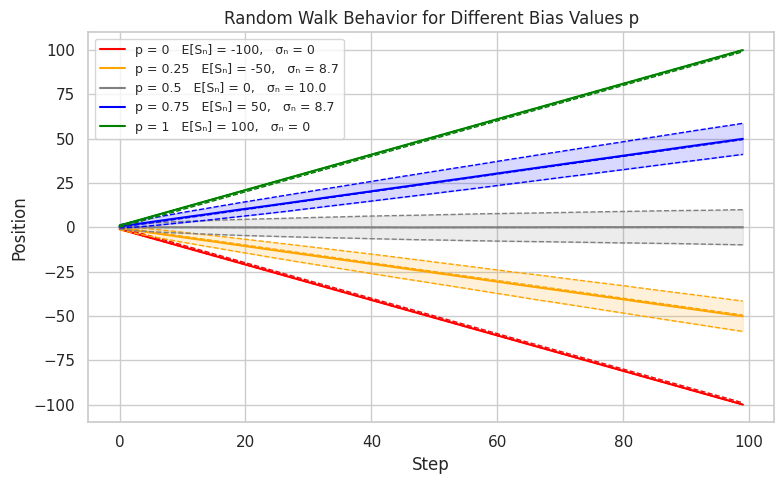

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
n_steps = 100
n_walks = 5000
p_values = [0, 0.25, 0.5, 0.75, 1]
rng = np.random.default_rng(seed=42)

colors = ["red", "orange", "gray", "blue", "green"]

fig, ax = plt.subplots(figsize=(8, 5))

handles = []
labels = []

for p, color in zip(p_values, colors):

    steps = rng.choice([1, -1], size=(n_walks, n_steps), p=[p, 1-p])
    walks = steps.cumsum(axis=1)

    mean_t = walks.mean(axis=0)
    std_t = walks.std(axis=0)

    drift = (2*p - 1) * np.arange(n_steps)

    # theoretical sigma
    sigma_n = np.sqrt(4 * n_steps * p * (1 - p))

    # format sigma: show "0" instead of "0.0"
    sigma_str = "0" if sigma_n == 0 else f"{sigma_n:.1f}"

    label = (
        f"p = {p}   "
        f"E[Sₙ] = {n_steps*(2*p-1):.0f},   "
        f"σₙ = {sigma_str}"
    )

    h, = ax.plot(mean_t, color=color, label=label)
    handles.append(h)
    labels.append(label)

    ax.fill_between(
        np.arange(n_steps),
        mean_t - std_t,
        mean_t + std_t,
        color=color,
        alpha=0.15
    )

    ax.plot(mean_t + std_t, "--", color=color, linewidth=1)
    ax.plot(mean_t - std_t, "--", color=color, linewidth=1)

    ax.plot(drift, "--", color=color, linewidth=1)

ax.set_title("Random Walk Behavior for Different Bias Values p")
ax.set_xlabel("Step")
ax.set_ylabel("Position")
ax.grid(True)

# legend with correct colors and labels
ax.legend(handles, labels, fontsize=9)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_random_walk_as_function_of_p")

### Geometric and Exponential Distributions


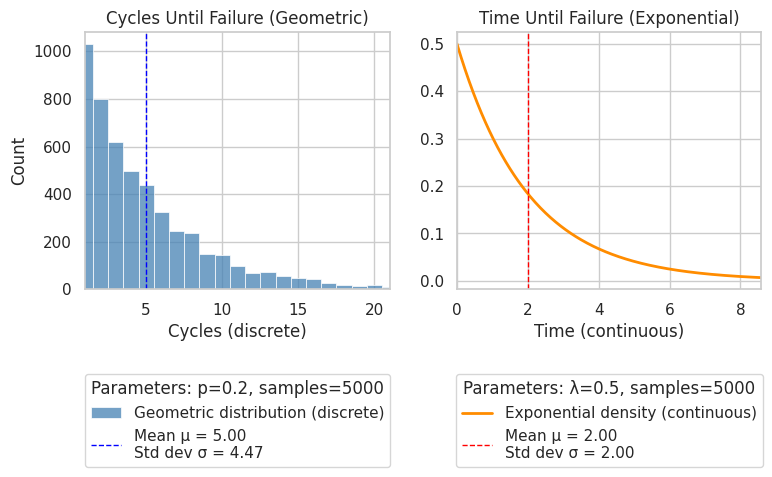

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set(style="whitegrid")

# -----------------------------
# Discrete Example: Cycles Until Failure (Geometric)
# -----------------------------
p = 0.2
n = 5000

cycles = np.random.geometric(p, size=n)

# Geometric mean and std dev
mu_geo = 1 / p
sigma_geo = np.sqrt((1 - p) / (p**2))

max_cycles = np.percentile(cycles, 99).astype(int)

# -----------------------------
# Continuous Example: Time Until Failure (Exponential)
# -----------------------------
rate = 0.5
times = np.random.exponential(1 / rate, size=n)

# Exponential mean and std dev
mu_exp = 1 / rate
sigma_exp = 1 / rate

max_time = np.percentile(times, 99)

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ---- Discrete: Geometric ----
bars_geo = sns.histplot(
    cycles,
    bins=range(1, max_cycles + 1),
    discrete=True,
    ax=axes[0],
    color="steelblue"
)

line_geo_mean = axes[0].axvline(
    mu_geo, color="blue", linestyle="--", linewidth=1
)

axes[0].set_title("Cycles Until Failure (Geometric)")
axes[0].set_xlabel("Cycles (discrete)")
axes[0].set_xlim(1, max_cycles)

axes[0].legend(
    [
        bars_geo.patches[0],
        line_geo_mean
    ],
    [
        "Geometric distribution (discrete)",
        f"Mean μ = {mu_geo:.2f}\nStd dev σ = {sigma_geo:.2f}"
    ],
    title=f"Parameters: p={p}, samples={n}",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30)
)

# ---- Continuous: Exponential ----
# True exponential PDF only
x_vals = np.linspace(0, max_time, 300)
pdf_vals = rate * np.exp(-rate * x_vals)

pdf_line = axes[1].plot(
    x_vals,
    pdf_vals,
    color="darkorange",
    linewidth=2
)[0]

line_exp_mean = axes[1].axvline(
    mu_exp, color="red", linestyle="--", linewidth=1
)

axes[1].set_title("Time Until Failure (Exponential)")
axes[1].set_xlabel("Time (continuous)")
axes[1].set_xlim(0, max_time)

axes[1].legend(
    [
        pdf_line,
        line_exp_mean
    ],
    [
        "Exponential density (continuous)",
        f"Mean μ = {mu_exp:.2f}\nStd dev σ = {sigma_exp:.2f}"
    ],
    title=f"Parameters: λ={rate}, samples={n}",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30)
)

plt.subplots_adjust(bottom=0.32)
plt.tight_layout()
plt.show()
export_plot(fig, "sim_geometric_exponential")

### Poisson Process and Exponential Interarrival Times

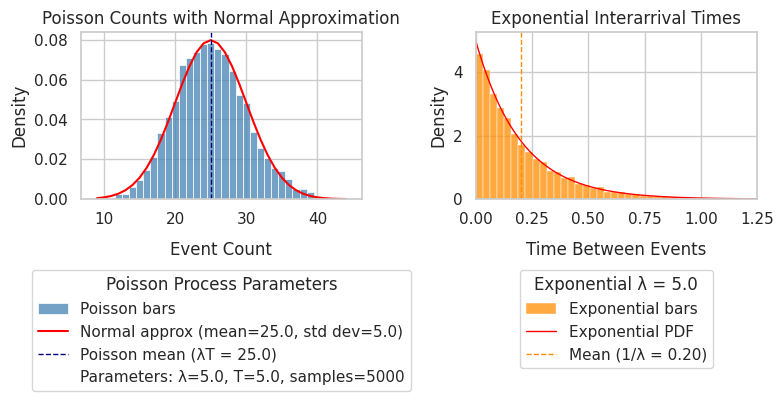

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

np.random.seed(42)

sns.set(style="whitegrid")

# -----------------------------
# Parameters
# -----------------------------
lam = 5.0       # event rate λ
T = 5.0         # interval length
n_samples = 5000

# -----------------------------
# 1. Poisson counts
# -----------------------------
mean_count = lam * T
std_dev = np.sqrt(mean_count)

counts = np.random.poisson(mean_count, size=n_samples)

x_vals = np.arange(counts.min(), counts.max() + 1)
normal_pdf = norm.pdf(x_vals, loc=mean_count, scale=std_dev)

# -----------------------------
# 2. Exponential interarrival times
# -----------------------------
interarrivals = np.random.exponential(1 / lam, size=n_samples)
mean_interarrival = 1 / lam

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ---- Left: Poisson counts with Normal overlay ----
bars_left = sns.histplot(
    counts,
    bins=range(counts.min(), counts.max() + 1),
    discrete=True,
    stat="density",
    color="steelblue",
    ax=axes[0]
)

line_normal, = axes[0].plot(
    x_vals,
    normal_pdf,
    color="red"
)

line_mean_left = axes[0].axvline(
    mean_count, color="navy", linestyle="--", linewidth=1
)

axes[0].set_title("Poisson Counts with Normal Approximation")
axes[0].set_xlabel("Event Count", labelpad=10)

handles_left = [
    bars_left.patches[0],
    line_normal,
    line_mean_left,
    plt.Line2D([], [], color='none')
]

labels_left = [
    "Poisson bars",
    f"Normal approx (mean={mean_count:.1f}, std dev={std_dev})",
    f"Poisson mean (λT = {mean_count:.1f})",
    f"Parameters: λ={lam}, T={T}, samples={n_samples}"
]

axes[0].legend(
    handles_left,
    labels_left,
    title="Poisson Process Parameters",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.38)
)

# ---- Right: Exponential interarrival times with PDF ----
bars_right = sns.histplot(
    interarrivals,
    bins=60,
    stat="density",
    color="darkorange",
    ax=axes[1]
)

# Exponential PDF
t_vals = np.linspace(0, interarrivals.max(), 300)
exp_pdf = lam * np.exp(-lam * t_vals)

line_pdf, = axes[1].plot(
    t_vals,
    exp_pdf,
    color="red",
    linewidth=1
)

line_mean_right = axes[1].axvline(
    mean_interarrival, color="darkorange", linestyle="--", linewidth=1
)

axes[1].set_title("Exponential Interarrival Times")
axes[1].set_xlabel("Time Between Events", labelpad=10)
axes[1].set_xlim(0, 1.25)

axes[1].legend(
    [
        bars_right.patches[0],
        line_pdf,
        line_mean_right
    ],
    [
        "Exponential bars",
        "Exponential PDF",
        f"Mean (1/λ = {mean_interarrival:.2f})"
    ],
    title=f"Exponential λ = {lam}",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.38)
)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_poisson_counts_vs_exponential_times")

### Poisson Process: Count Levels vs. Interarrival Durations

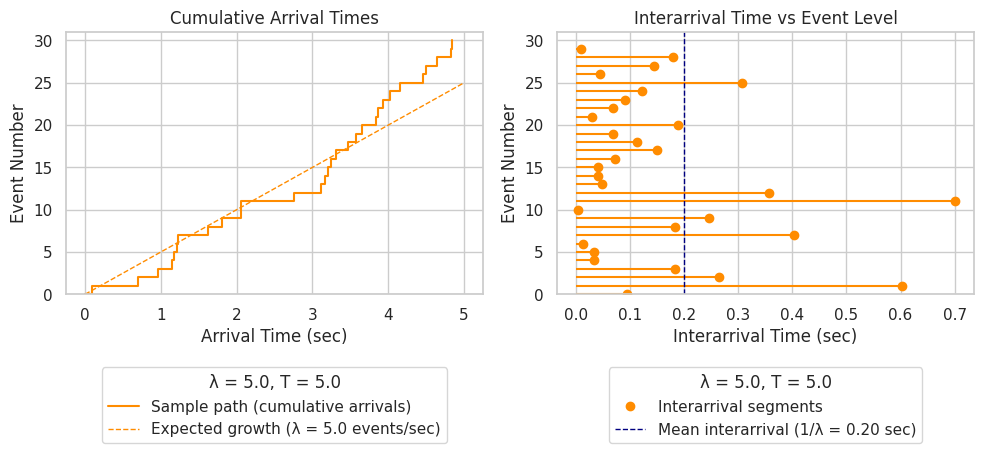

In [16]:
# Poisson Process: Count Levels vs. Interarrival Durations (Aligned by Event Index)
import numpy as np
import matplotlib.pyplot as plt

# X_k is the waiting time between event k-1 and k,
# so we plot X_k on row k-1 to match the flat level of N(t).

np.random.seed(42)

lam = 5.0
T = 5.0

# Simulate many interarrival times
interarrivals_full = np.random.exponential(1 / lam, size=2000)

# Compute arrival times
arrival_times_full = np.cumsum(interarrivals_full)

# Keep only arrivals within unified window T
mask = arrival_times_full <= T
arrival_times = arrival_times_full[mask]
interarrivals_used = interarrivals_full[mask]

n_events = len(arrival_times)

# Event numbers 1..n for arrivals
event_numbers = np.arange(1, n_events + 1)

# For N(t), prepend time 0 and count 0
times_N = np.concatenate(([0.0], arrival_times))
counts_N = np.arange(0, n_events + 1)  # 0..n

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---- Plot 1: Cumulative arrivals N(t) ----
line_path, = axes[0].step(
    times_N,
    counts_N,
    where='post',
    color='darkorange'
)

line_expected, = axes[0].plot(
    [0, T],
    [0, lam * T],
    linestyle="--",
    color="darkorange",
    linewidth=1
)

axes[0].set_title("Cumulative Arrival Times")
axes[0].set_xlabel("Arrival Time (sec)")
axes[0].set_ylabel("Event Number")

axes[0].legend(
    [line_path, line_expected],
    [
        "Sample path (cumulative arrivals)",
        f"Expected growth (λ = {lam} events/sec)"
    ],
    title=f"λ = {lam}, T = {T}",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25)
)

# ---- Plot 2: Interarrival time vs level of N(t) ----
# X_k lives on the flat segment where N(t) = k-1, so use row k-1
levels_for_X = np.arange(0, n_events)  # 0..n-1

for x, y in zip(interarrivals_used, levels_for_X):
    axes[1].hlines(y, 0, x, color='darkorange')
    axes[1].plot(x, y, 'o', color='darkorange')

axes[1].set_title("Interarrival Time vs Event Level")
axes[1].set_xlabel("Interarrival Time (sec)")
axes[1].set_ylabel("Event Number")

axes[1].axvline(1/lam, color="navy", linestyle="--", linewidth=1)

axes[1].legend(
    [axes[1].lines[0], axes[1].lines[-1]],
    ["Interarrival segments", f"Mean interarrival (1/λ = {1/lam:.2f} sec)"],
    title=f"λ = {lam}, T = {T}",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25)
)

# ---- Shared y-axis: show only every 5th level ----
ymin = 0
ymax = n_events + 1

for ax in axes:
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(np.arange(0, ymax + 1, 5))

plt.tight_layout()
plt.show()
export_plot(fig, "sim_poisson_cumulative_times_vs_interarrival_times")